In [36]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.neighbors import LocalOutlierFactor

In [3]:
df1_train  = pd.read_csv('../data/phase_1/Training_dataset_1.csv', na_values=['-999.25']) 
df2_train  = pd.read_csv('../data/phase_1/Training_dataset_2.csv', na_values=['-999.25'])  
df3_train  = pd.read_csv('../data/phase_1/Training_dataset_3.csv', na_values=['-999.25'])  

df1_test   = pd.read_csv('../data/phase_1/Test_dataset_1.csv')
df2_test   = pd.read_csv('../data/phase_1/Test_dataset_2.csv')
df3_test   = pd.read_csv('../data/phase_1/Test_dataset_3.csv')

In [14]:
import missingno as msno
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt

def debug_missing_data(df, threshold=20):
    """
    Debug missing data analysis for numerical columns with detailed shape information at each step.
    
    Parameters:
    df (pandas.DataFrame): Input DataFrame
    threshold (float): Max percentage of missing values allowed
    
    Returns:
    pandas.DataFrame: Imputed DataFrame with only numerical columns, or None if process fails
    """
    # Step 1: Select only numeric columns
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    df_numeric = df[numeric_cols].copy()
    
    print("Step 1: Initial DataFrame Info")
    print(f"Original DataFrame shape: {df.shape}")
    print(f"Numeric-only DataFrame shape: {df_numeric.shape}")
    print("\nNumeric columns selected:")
    print(df_numeric.columns.tolist())
    
    # Step 2: Calculate missing percentages for numeric columns
    missing_percentage = df_numeric.isnull().sum() / len(df_numeric) * 100
    missing_df = pd.DataFrame({
        'Column': missing_percentage.index,
        'Missing Percentage': missing_percentage.values
    }).sort_values('Missing Percentage', ascending=False)
    
    print("\nStep 2: Missing Value Analysis (Numeric Columns Only)")
    print(missing_df)
    
    # Step 3: Filter columns with missing data below threshold
    cols_with_missing = missing_df[missing_df['Missing Percentage'] < threshold]['Column'].tolist()
    print(f"\nStep 3: Numeric columns with <{threshold}% missing values:")
    print(cols_with_missing)
    
    
    # Step 3.1: Filter columns with missing data below threshold
    cols_with_missing1 = missing_df[missing_df['Missing Percentage'] > threshold]['Column'].tolist()
    print(f"\nStep 3.1: Numeric columns with >{threshold}% missing values:")
    print(cols_with_missing1)
    
    if len(cols_with_missing) > 0:
        # Step 4: Prepare data for imputation
        df_to_impute = df_numeric[cols_with_missing].copy()
        print("\nStep 4: Pre-imputation Data Check")
        print(f"Shape of data to be imputed: {df_to_impute.shape}")
        print("\nColumns to be imputed:")
        print(df_to_impute.columns.tolist())
        
        # Step 5: Check data types
        print("\nStep 5: Data Types Check")
        print(df_to_impute.dtypes)
        
        # Step 6: Attempt imputation
        print("\nStep 6: Attempting Imputation")
        try:
            imputer = KNNImputer()
            print("Starting imputer...")
            df_filled_array = imputer.fit_transform(df_to_impute)
            print("Imputation completed")
            print(f"Shape of training data: {df_to_impute.shape}")
            print(f"Shape of imputed array: {df_filled_array.shape}")
            
            # Create DataFrame from imputed values
            df_filled = pd.DataFrame(df_filled_array, columns=df_to_impute.columns)
            print(f"Shape of final DataFrame: {df_filled.shape}")
            
            # Verify column alignment
            print("\nColumn alignment check:")
            print("Input columns:", df_to_impute.columns.tolist())
            print("Output columns:", df_filled.columns.tolist())
            
            return df_filled
            
        except ValueError as e:
            print(f"\nError during imputation: {e}")
            return None
    else:
        print("No numeric columns with missing data found above the threshold.")
        return None

# Usage

debug_missing_data(df3_train).to_csv('../data/phase_1/training_dataset_3_imputed.csv', index=False)

Step 1: Initial DataFrame Info
Original DataFrame shape: (6995, 89)
Numeric-only DataFrame shape: (6995, 88)

Numeric columns selected:
['AD Delta-P SP (psi)', 'AD ROP SP (ft/hr)', 'AD Torque SP (kft·lbf)', 'AD WOB SP (klb)', 'Accum Trip In (bbl)', 'Accum Trip Out (bbl)', 'Annular Velocity (ft/min)', 'BHA Length (ft)', 'Bit MSE (psi)', 'Bit Position (ft)', 'Bit RPM (RPM)', 'Bit Size (in)', 'Bit Time (hr)', 'Bit Weight (klb)', 'Block Height (ft)', 'Bttm Pipe Temp (°F)', 'Casing Pressure (psi)', 'Circulating Hrs (hr)', 'Co. Man G/L (bbl)', 'Cont Az (deg)', 'Cont Inc (deg)', 'Depth of Cut (ft)', 'Depth(ft)', 'Diff Press (psi)', 'East West Horizontal (ft)', 'Flow Deviation (%)', 'Flow In Rate (galUS/min)', 'Flow Out Percent (%)', 'G/L Rate - 1 Min (bbl/min)', 'G/L Rate - 5 Min (bbl/min)', 'Gain Loss (bbl)', 'Gain Loss - Spare (bbl)', 'Gamma Depth (ft)', 'Gamma Ray (offset) (API)', 'Hole Depth (ft)', 'Hook Load (klb)', 'Lst Jnt Time (s)', 'ML Mud Temp IN (°F)', 'ML Mud Temp OUT (°F)', 'MSE 

In [17]:
df1_clean = pd.read_csv('../data/phase_1/training_dataset_1_imputed.csv')
df2_clean = pd.read_csv('../data/phase_1/training_dataset_2_imputed.csv')
df3_clean = pd.read_csv('../data/phase_1/training_dataset_3_imputed.csv')

In [25]:
# Get the column names of df1_clean and df2_clean
df1_columns = set(df1_clean.columns)
df2_columns = set(df2_clean.columns)


# get the columns that in df2 but not in df1
df2_not_in_df1 = df2_columns - df1_columns

In [32]:
df2_clean.drop(columns=list(df2_not_in_df1), inplace=True)

In [33]:
df3_clean.drop(columns=list(df2_not_in_df1), inplace=True)

In [34]:
df2_clean.to_csv('../data/phase_1/training_dataset_2_imputed.csv', index=False)

In [35]:
df3_clean.to_csv('../data/phase_1/training_dataset_3_imputed.csv', index=False)

In [62]:
# Find the 99th percentile (top 1%)
clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
clf.fit_predict(df3_clean)
scores = clf.negative_outlier_factor_
scores = (scores - np.min(scores)) / (np.max(scores) - np.min(scores))
threshold = np.percentile(scores, 99)
filtered_scores = scores[scores < threshold]
print(f"Original length: {len(scores)}")
print(f"New length: {len(filtered_scores)}")
print(f"Removed {len(scores) - len(filtered_scores)} points")
print(f"Threshold value: {threshold:.4f}")

# Get indices of points to keep
keep_indices = np.where(scores < threshold)[0]

# Or get indices of points to remove
remove_indices = np.where(scores >= threshold)[0]

# Apply to your original data
df3_clean = df3_clean[scores < threshold]

Original length: 6925
New length: 6855
Removed 70 points
Threshold value: 0.9995


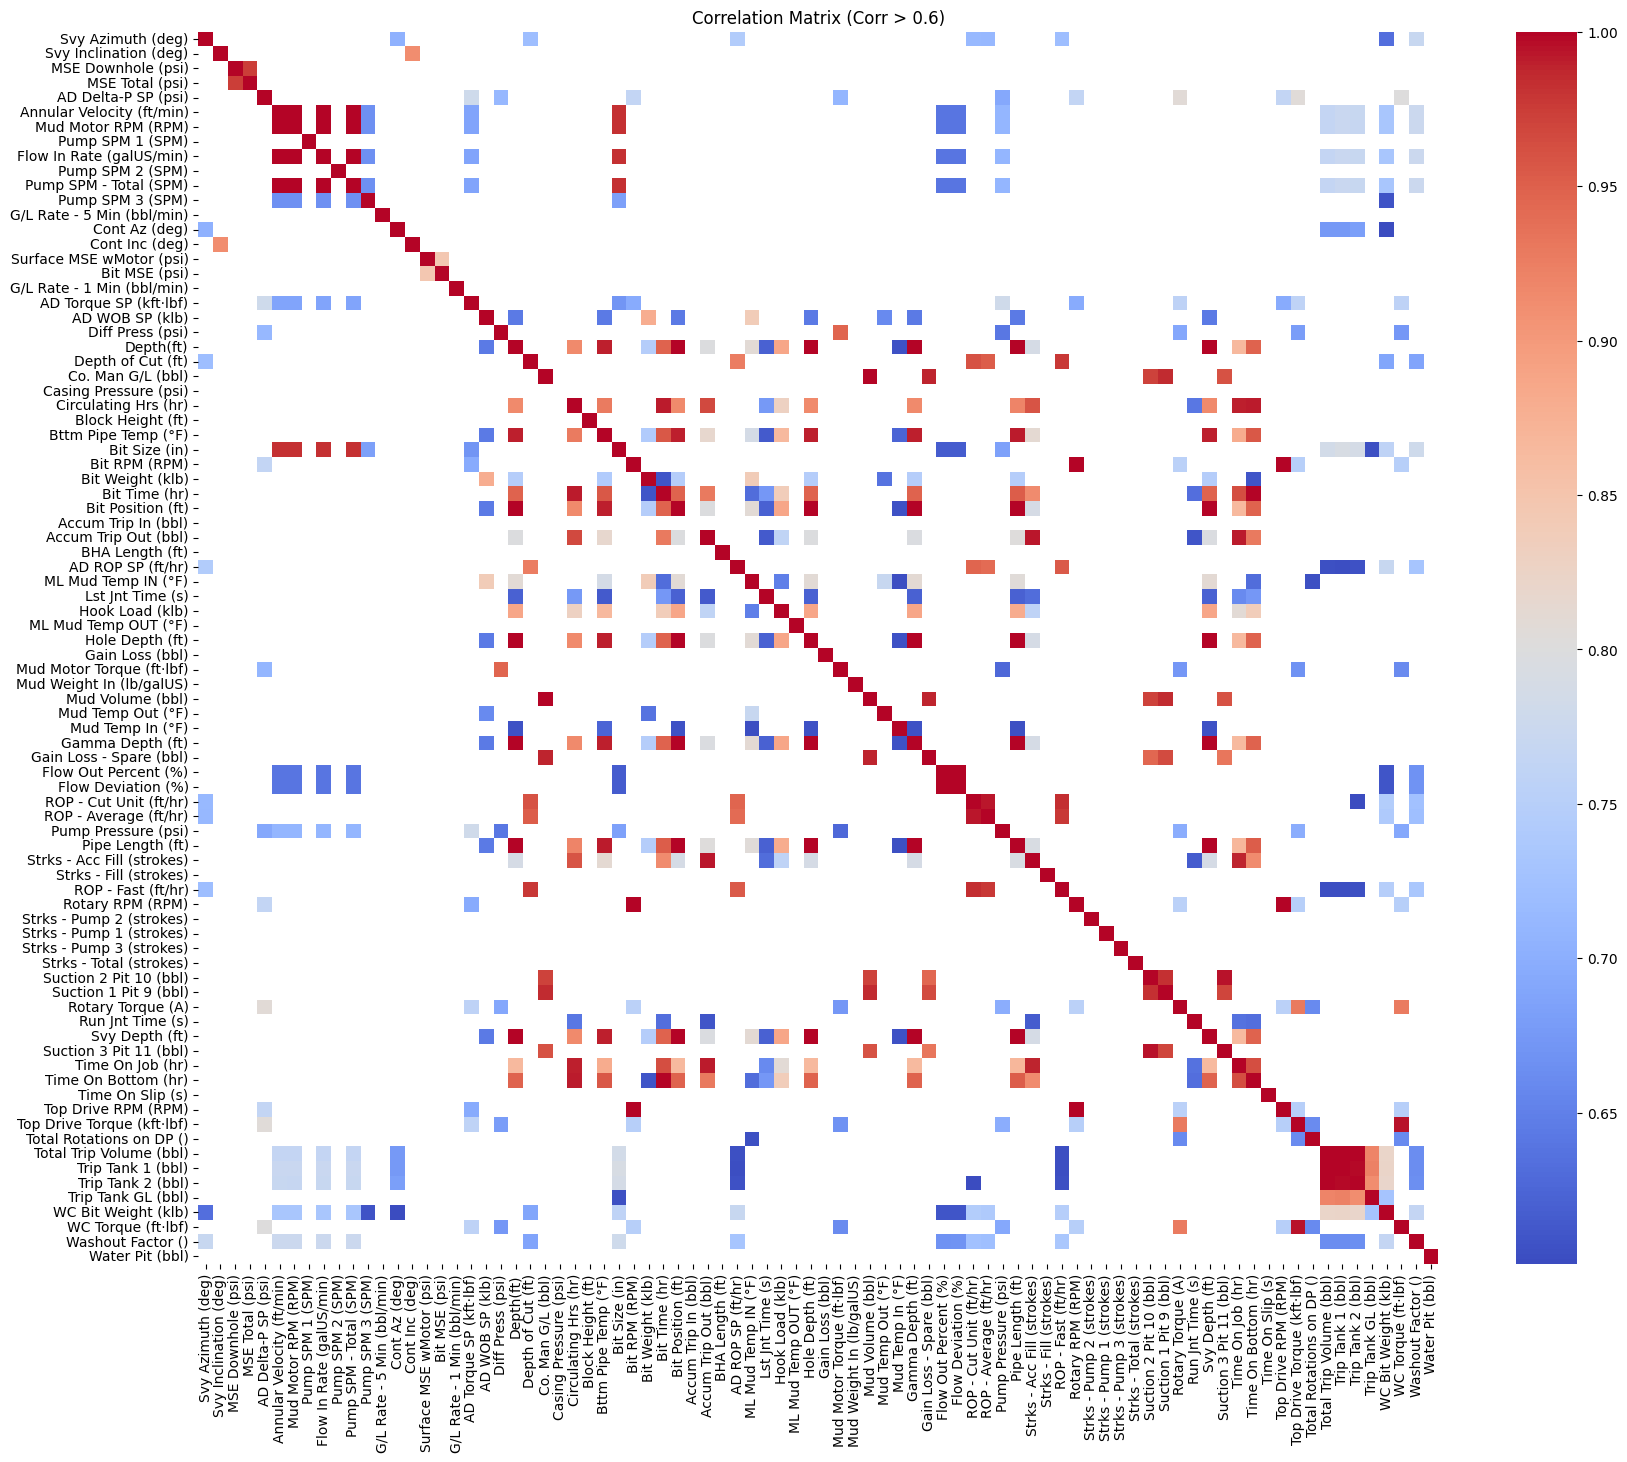

In [84]:
import seaborn as sns

# Create correlation matrix
corr = df3_clean.corr()
# Filter correlation matrix
high_corr = corr[corr>0.6]

# Plot correlation matrix heatmap



plt.figure(figsize=(20, 16))
sns.heatmap(high_corr, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix (Corr > 0.6)')
plt.show()

In [101]:
filtered_corr = corr.loc['Bttm Pipe Temp (°F)', :][corr.loc['Bttm Pipe Temp (°F)', :]>0.5].sort_values(ascending=False)

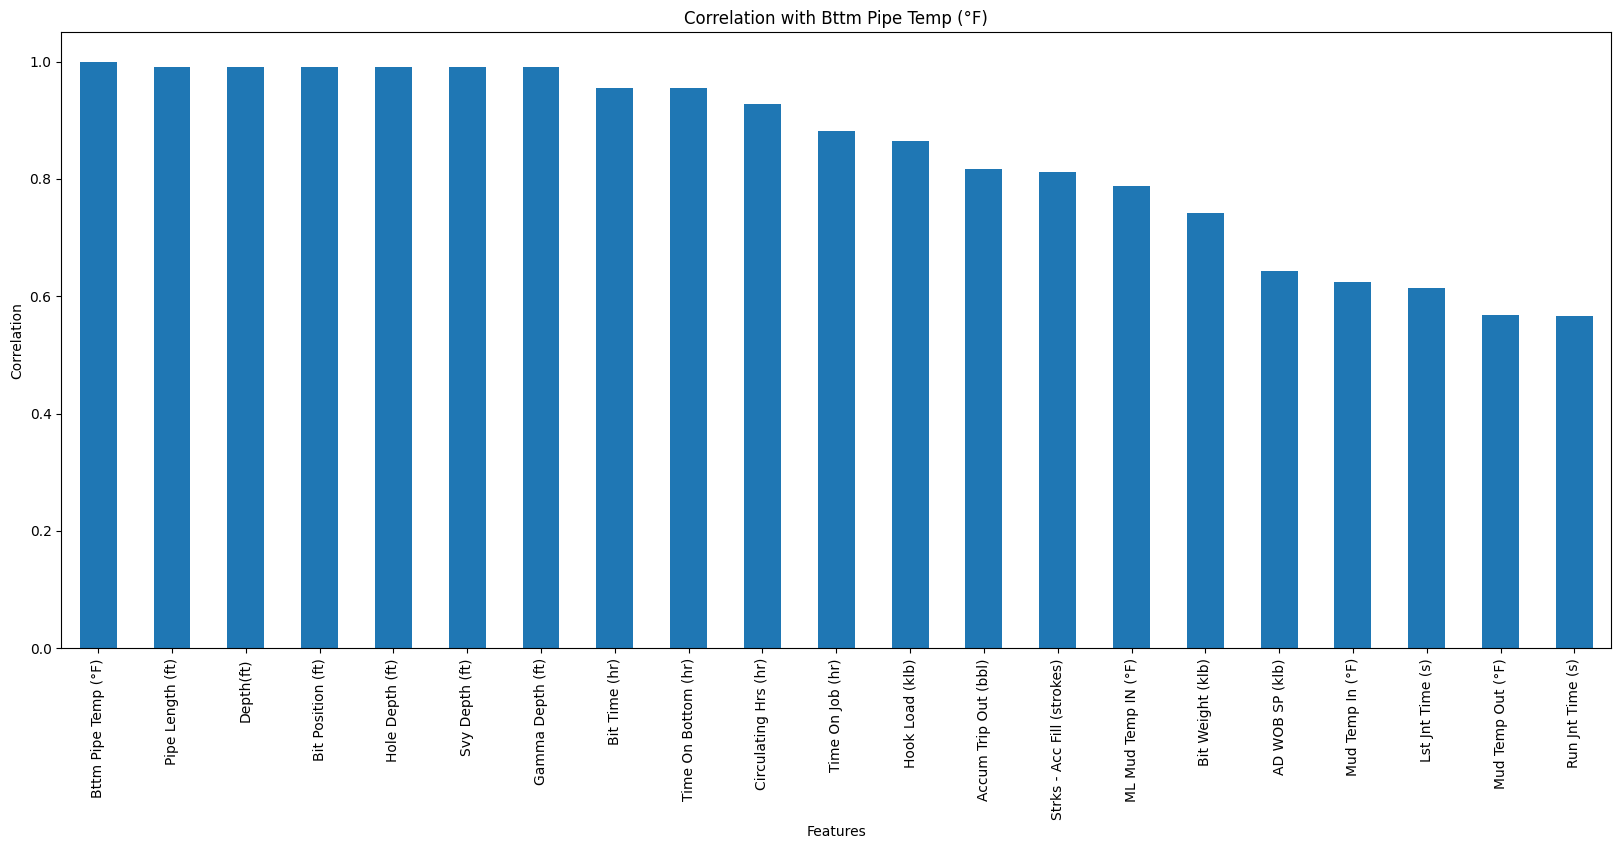

In [102]:
# draw a barchart for filtered_corr
plt.figure(figsize=(20, 8))
filtered_corr.plot(kind='bar')
plt.title('Correlation with Bttm Pipe Temp (°F)')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.show()


In [112]:
# display only more than 0.5 correlation
filtered_corr = filtered_corr[filtered_corr>0.9]

In [113]:
filtered_corr

Bttm Pipe Temp (°F)     1.000000
Pipe Length (ft)        0.991367
Depth(ft)               0.990280
Bit Position (ft)       0.990280
Hole Depth (ft)         0.990280
Svy Depth (ft)          0.990214
Gamma Depth (ft)        0.990206
Bit Time (hr)           0.954932
Time On Bottom (hr)     0.954932
Circulating Hrs (hr)    0.928182
Name: Bttm Pipe Temp (°F), dtype: float64